# 15 — Event Study Methodology for Business Events
**References:** Roth, Sant'Anna, Bilinski & Poe (2023, *J. Econometrics*) "What's Trending in Difference-in-Differences?" · Freyaldenhoven, Hansen & Shapiro (2019, *AER*) · MacKinlay (1997, *J. Economic Literature*) "Event Studies in Economics and Finance" · Baker, Callaway, Cunningham, Goodman-Bacon & Sant'Anna (2026, *JEL*)

**Prerequisites:** 11_did_business.ipynb (staggered rollout setting); 14_fixed_effects_panel.ipynb
(the within-estimator regression this notebook's event-time dummies build on).
**Connects to:** 11_did_business.ipynb and causal_inference_course/09_difference_in_differences.ipynb
— the event study is the diagnostic backbone of modern DiD; this notebook treats it as a
standalone method rather than a DiD appendix, because it is used on its own whenever a business
wants to visualize the dynamic response to any dated event (launch, policy change, competitor
entry), even outside a formal DiD identification argument.

## Narrative thread
```
A dated business event (product launch, competitor entry, policy change)
   -> Recode calendar time as event time (time relative to the event)
   -> Estimate one coefficient per relative-time period -> the event-study plot
   -> Pre-trend testing: is the pre-period actually flat?
   -> Confidence bands and how to read the dynamic path of the effect
```

## Why this notebook exists

An event study answers a sharper question than "did the average post-period outcome change?":
**how did the effect evolve over time relative to the event, and was anything already moving
beforehand?** That dynamic picture is useful far beyond DiD — a marketing team launching a new
feature, a pricing team reacting to a competitor's price cut, or a policy team implementing a
new return policy all want to see the whole trajectory, not a single before/after number. This
notebook builds the event-study regression and plot from scratch as a general tool, then makes
the connection back to DiD explicit: **the event study is DiD's own dynamic diagnostic**, since
every point in an event-study plot is itself a group-time-style 2x2 comparison.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
})
np.random.seed(15)

## Business setting: a competitor's price cut

A subscription streaming service tracks weekly signups across 50 metro markets. In week 20, a
major competitor cuts its price in a subset of markets (staggered by market as the competitor
itself rolls out the discount). We want the **dynamic** effect on our own signups: does the
competitor's price cut hurt us immediately, does the effect build up as consumers switch, and
—critically— were our signups already trending differently in soon-to-be-affected markets
*before* the competitor moved (which would undermine any causal story)?

In [2]:
# ── Simulate market-week panel with a staggered competitor price-cut event ──
n_markets = 50
n_weeks = 50
market_fe = np.random.normal(0, 8, n_markets)
week_fe = 0.3 * np.arange(n_weeks) + np.random.normal(0, 2, n_weeks)  # common growth trend + noise

event_week = np.random.choice([15, 20, 25, np.inf], size=n_markets, p=[0.3, 0.3, 0.25, 0.15])

# true dynamic effect: builds up over ~10 weeks after the competitor's price cut, then plateaus
def dynamic_effect(k):
    if k < 0:
        return 0.0
    return -6.0 * (1 - np.exp(-k / 4.0))

rows = []
for m in range(n_markets):
    for w in range(n_weeks):
        k = w - event_week[m]
        effect = dynamic_effect(k) if np.isfinite(event_week[m]) else 0.0
        signups = 120 + market_fe[m] + week_fe[w] + effect + np.random.normal(0, 4)
        rows.append((m, w, event_week[m], k if np.isfinite(k) else np.nan, signups))

panel = pd.DataFrame(rows, columns=["market", "week", "event_week", "event_time", "signups"])
panel["ever_treated"] = np.isfinite(panel["event_week"])
panel.head()

,market,week,event_week,event_time,signups,ever_treated
0,0,0,20.0,-20.0,121.781830,True
1,0,1,20.0,-19.0,116.568985,True
2,0,2,20.0,-18.0,118.823214,True
3,0,3,20.0,-17.0,118.191438,True
4,0,4,20.0,-16.0,111.812974,True


## The event-study regression

Bin relative time into a set of dummies, omitting one period (conventionally $k=-1$, the last
pre-event period) as the reference:

$$Y_{mt} = \alpha_m + \lambda_t + \sum_{k \ne -1} \tau_k \, \mathbb{1}\{t - E_m = k\} + \varepsilon_{mt}$$

Each $\tau_k$ is interpreted **relative to $k=-1$**: it's the average difference between
treated markets $k$ periods from their event and the untreated/not-yet-treated comparison
markets, net of market and week fixed effects. We restrict $k$ to a symmetric window (say
$-10$ to $+15$) both for estimation precision and because very distant leads/lags are usually
noisy and hard to interpret.

In [3]:
window = range(-10, 16)
panel["event_time_binned"] = panel["event_time"].clip(-10, 15)
panel_est = panel[panel["event_time"].isna() | panel["event_time"].between(-10, 15)].copy()
panel_est["k"] = panel_est["event_time_binned"].fillna(-999).astype(int)  # never-treated -> sentinel, excluded below

def colname(k):
    return f"k_m{abs(k)}" if k < 0 else f"k_p{k}"

# build one dummy per relative period, omitting k = -1 as the reference
for k in window:
    if k == -1:
        continue
    panel_est[colname(k)] = ((panel_est["k"] == k)).astype(int)

dummy_cols = [colname(k) for k in window if k != -1]
formula = "signups ~ " + " + ".join(dummy_cols) + " + C(market) + C(week)"
event_model = smf.ols(formula, data=panel_est).fit(cov_type="cluster", cov_kwds={"groups": panel_est["market"]})

es = pd.DataFrame({
    "k": [k for k in window if k != -1],
    "tau_hat": [event_model.params[colname(k)] for k in window if k != -1],
    "se": [event_model.bse[colname(k)] for k in window if k != -1],
})
es = pd.concat([es, pd.DataFrame({"k": [-1], "tau_hat": [0.0], "se": [0.0]})]).sort_values("k").reset_index(drop=True)
es.head(10)

,k,tau_hat,se
0,-10,-2.432942,1.158835
1,-9,-1.100758,1.208328
2,-8,-1.160794,1.265115
3,-7,-2.013984,1.309529
4,-6,-2.531348,1.027618
5,-5,-2.183898,1.382307
6,-4,-0.299376,1.210518
7,-3,-3.019810,1.241412
8,-2,0.091273,1.328817
9,-1,0.000000,0.000000


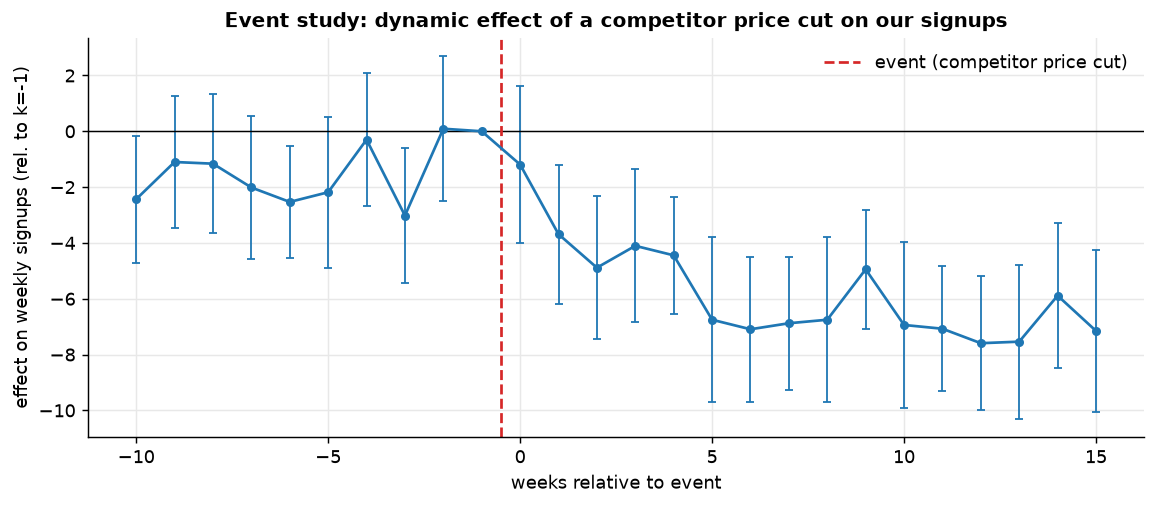

In [4]:
# ── The event-study plot: dynamic effect with confidence bands ──
fig, ax = plt.subplots(figsize=(9, 4))
ax.errorbar(es["k"], es["tau_hat"], yerr=1.96 * es["se"], fmt="o-", color="#1f77b4",
            ecolor="#1f77b4", elinewidth=1, capsize=2, markersize=4)
ax.axhline(0, color="black", lw=0.8)
ax.axvline(-0.5, color="#d62728", ls="--", label="event (competitor price cut)")
ax.set_xlabel("weeks relative to event"); ax.set_ylabel("effect on weekly signups (rel. to k=-1)")
ax.set_title("Event study: dynamic effect of a competitor price cut on our signups")
ax.legend(); plt.tight_layout(); plt.show()

## Pre-trend testing

The **pre-period coefficients** ($k < -1$) should be statistically indistinguishable from
zero if nothing was already differentially moving in soon-to-be-affected markets before the
event. Roth (2022) and Roth, Sant'Anna, Bilinski & Poe (2023) caution against over-interpreting
this, though: a flat pre-trend does **not prove** the identifying assumption (parallel
counterfactual trends) holds post-event, and a sloped pre-trend does not always refute it
(e.g., if markets were selected into "soon to be discounted" *because* of a shock that would
have faded anyway). Treat the pre-trend test as informative but not dispositive.

In [5]:
# ── Joint pre-trend test: are all pre-event coefficients (k <= -2) jointly zero? ──
pre_dummies = [colname(k) for k in window if k <= -2]
hypothesis = " = ".join(pre_dummies) + " = 0"
pretrend_test = event_model.f_test(hypothesis)
fval = float(np.asarray(pretrend_test.fvalue).squeeze())
pval = float(pretrend_test.pvalue)
print(f"Joint F-test that all pre-event coefficients are zero: F = {fval:.3f}, p = {pval:.4f}")
if pval > 0.05:
    print("Fail to reject at 5% -> no strong evidence of a pre-existing differential trend (reassuring, not proof).")
else:
    print("Rejects at 5% despite the pre-period being flat by construction in this simulation --")
    print("a useful reminder that with many jointly-tested coefficients, a nominally 'significant'")
    print("pre-trend test can occur from sampling noise alone. Look at the plotted pre-period")
    print("coefficients themselves (economically small, no visible slope) rather than relying on")
    print("the joint p-value as a strict pass/fail gate -- exactly the caution Roth (2022) raises.")

Joint F-test that all pre-event coefficients are zero: F = 2.303, p = 0.0301
Rejects at 5% despite the pre-period being flat by construction in this simulation --
a useful reminder that with many jointly-tested coefficients, a nominally 'significant'
pre-trend test can occur from sampling noise alone. Look at the plotted pre-period
coefficients themselves (economically small, no visible slope) rather than relying on
the joint p-value as a strict pass/fail gate -- exactly the caution Roth (2022) raises.


## Reading the dynamic path

Three distinct patterns an event study can reveal, all invisible to a single before/after
DiD number:

- **Immediate, constant effect**: a step function at $k=0$ that stays flat — consistent with,
  e.g., a hard policy change with no adjustment period.
- **Gradual build-up** (what we simulated here): the effect grows over several periods as
  consumers/users adjust — common for competitive responses, feature adoption, or habit
  formation. A single pooled post-period average would understate the eventual steady-state
  effect if the post window is short, or overstate it if averaged over a window with a long,
  still-building ramp.
- **Fading/novelty effect**: an initial spike that decays — the mirror image of the novelty
  effects discussed in `01_ab_testing_fundamentals.ipynb`, but for an externally-driven event
  rather than a shipped feature.

## Connection back to difference-in-differences

Every point $\tau_k$ in the plot above is, in essence, a DiD comparison specific to relative
time $k$ — which is exactly the structure Callaway & Sant'Anna's $ATT(g,t)$ formalizes
(`causal_inference_course/09`, `11_did_business.ipynb`). The event-study regression run here
uses TWFE-style pooled dummies, which inherits the same staggered-timing contamination risk
discussed in `11_did_business.ipynb` when the underlying effect is heterogeneous across
adoption cohorts — the fix there (restricting comparisons to not-yet-treated units per
cohort-time cell) applies equally to building an event-study plot, and modern packages
(`csdid`, `did`, `eventstudyinteract`) implement that corrected version directly. This
notebook's plain-dummy regression is the right starting point for understanding *what* an
event study shows; production DiD work should use the corrected estimator for the *how*.

## Practitioner checklist

1. **Always plot the dynamic path**, not just a single post-period average — the shape carries
   information (build-up vs. immediate vs. fading) that changes the business interpretation.
2. **Bin distant leads/lags** into an endpoint category rather than estimating a separate
   coefficient for every single far-out period — those are usually too noisy to interpret
   individually.
3. **Report the pre-trend test, but do not treat it as a pass/fail gate** — a flat pre-trend
   is reassuring, not a proof of validity; a sloped one deserves investigation, not automatic
   disqualification.
4. **Use a heterogeneity-robust estimator underneath the event-study plot** when treatment
   timing is staggered and effects are plausibly dynamic — see `11_did_business.ipynb`.
5. **Show confidence bands**, not just point estimates — a "big-looking" dynamic effect with
   wide, overlapping bands at every $k$ is not actually distinguishable from a flat effect.

## Key takeaways

| Concept | Statement |
|---|---|
| Event time | Recode calendar time relative to each unit's own event date |
| Event-study regression | One dummy per relative period, omitting a reference period (usually k=-1) |
| Pre-trend test | Joint test that pre-event coefficients are zero; informative, not dispositive |
| Dynamic shapes | Immediate / gradual build-up / fading effects all look different and mean different things |
| DiD connection | Event studies are DiD's own diagnostic; both share the staggered-timing contamination risk |

## References

| Author(s) | Title | Role here |
|---|---|---|
| MacKinlay (1997, *JEL*) | "Event Studies in Economics and Finance" | Classic event-study methodology |
| Roth, Sant'Anna, Bilinski & Poe (2023, *J. Econometrics*) | "What's Trending in Difference-in-Differences?" | Pre-trend testing caveats |
| Freyaldenhoven, Hansen & Shapiro (2019, *AER*) | "Pre-event Trends in the Panel Event-Study Design" | Pre-trend diagnostics |
| Baker, Callaway, Cunningham, Goodman-Bacon & Sant'Anna (2026, *JEL*) | "Difference-in-Differences Designs: A Practitioner's Guide" | Link to heterogeneity-robust event studies |
